In [15]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv(
    "../data/processed/Student_Attendance_Summary.csv"
)

df.head()

,Student_ID,Student_Name,College_Name,Total_Sessions,Sessions_Attended,Average_Attendance_Minutes,Attendance_Percentage,Attendance_Std,Consistency_Score,Domain_Participation_Count,Engagement_Score,Eligible
0,ST0001,Sai Reddy,VIT AP,40,37,48.70,92.5,14.72,85.28,1,76.83,1
1,ST0002,Rohit Gupta,Narasaraopeta Engg,40,30,40.98,75.0,24.18,75.82,1,65.25,0
2,ST0003,Harsha Kumar,VNR VJIET,40,28,37.38,70.0,25.01,74.99,1,62.50,0
3,ST0004,Praveen Gupta,Gudlavalleru Engg,40,33,43.48,82.5,20.68,79.32,1,70.05,1
4,ST0005,Varun Patel,Andhra Loyola,40,27,35.90,67.5,25.50,74.50,1,61.10,0


In [17]:
X = df[
[
    'Total_Sessions',
    'Sessions_Attended',
    'Average_Attendance_Minutes',
    'Consistency_Score',
    'Domain_Participation_Count',
    'Engagement_Score'
]
]

y = df['Eligible']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
log_model = joblib.load(
    "../models/logistic_regression.pkl"
)

dt_model = joblib.load(
    "../models/decision_tree.pkl"
)

rf_model = joblib.load(
    "../models/random_forest.pkl"
)

In [20]:
print(X.columns.tolist())

['Total_Sessions', 'Sessions_Attended', 'Average_Attendance_Minutes', 'Consistency_Score', 'Domain_Participation_Count', 'Engagement_Score']


In [21]:
print(df.columns.tolist())

['Student_ID', 'Student_Name', 'College_Name', 'Total_Sessions', 'Sessions_Attended', 'Average_Attendance_Minutes', 'Attendance_Percentage', 'Attendance_Std', 'Consistency_Score', 'Domain_Participation_Count', 'Engagement_Score', 'Eligible']


In [22]:
models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

results = []

for name, model in models.items():

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0


In [23]:
results_df.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0


In [24]:
best_model = results_df.sort_values(
    by='Accuracy',
    ascending=False
).iloc[0]

best_model

Model        Logistic Regression
Accuracy                     1.0
Precision                    1.0
Recall                       1.0
F1 Score                     1.0
Name: 0, dtype: object

In [25]:
rf_predictions = rf_model.predict(
    X_test
)

print(
    classification_report(
        y_test,
        rf_predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        78
           1       1.00      1.00      1.00       118

    accuracy                           1.00       196
   macro avg       1.00      1.00      1.00       196
weighted avg       1.00      1.00      1.00       196



In [26]:
cm = confusion_matrix(
    y_test,
    rf_predictions
)

cm

array([[ 78,   0],
       [  0, 118]])

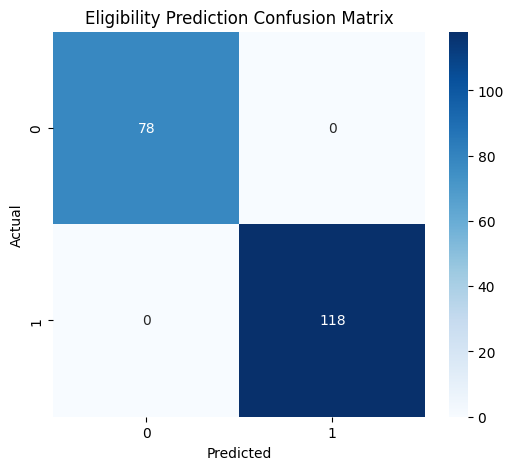

In [27]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Eligibility Prediction Confusion Matrix"
)

plt.xlabel(
    'Predicted'
)

plt.ylabel(
    'Actual'
)

plt.savefig(
    '../visualizations/confusion_matrix.png'
)

plt.show()

In [28]:
importance = pd.DataFrame(
    {
        'Feature': X.columns,
        'Importance':
        rf_model.feature_importances_
    }
)

importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
1,Sessions_Attended,0.347593
5,Engagement_Score,0.339296
3,Consistency_Score,0.192636
2,Average_Attendance_Minutes,0.120475
0,Total_Sessions,0.000000
4,Domain_Participation_Count,0.000000


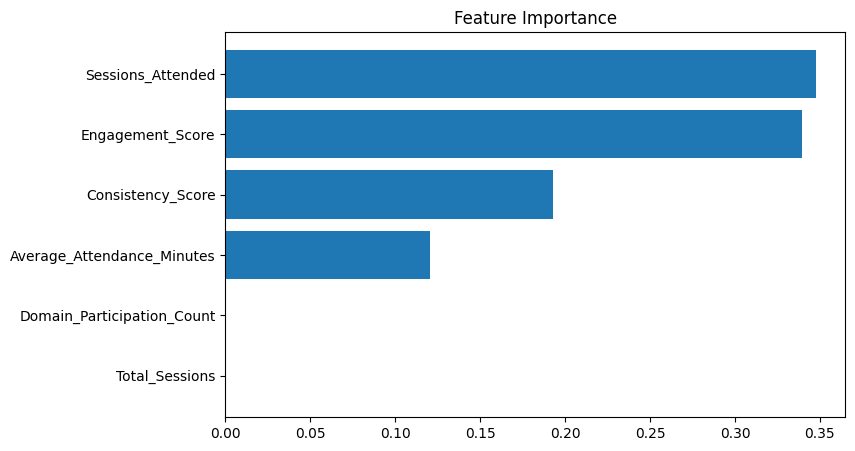

In [29]:
importance = importance.sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(8,5))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.title(
    'Feature Importance'
)

plt.show()

In [30]:
results_df.to_csv(
    "../outputs/model_evaluation_report.csv",
    index=False
)

print(
    "Evaluation Report Saved Successfully"
)

Evaluation Report Saved Successfully
